<a href="https://colab.research.google.com/github/Alhmmada/Bike-Sharing-Demand-Prediction/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AH2179 – Assignment 4: Neural Network Bike-Sharing Demand Prediction

This notebook develops, tunes and evaluates neural-network regression models for predicting hourly bike-sharing demand.


In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_7_Neural_networks/Exercise7BikeSharing.csv"

df = pd.read_csv(url)

print("Antal rader och kolumner:", df.shape)
print("Antal saknade värden:", df.isnull().sum().sum())
print("Antal dubbletter:", df.duplicated().sum())

df.head()

Antal rader och kolumner: (17379, 17)
Antal saknade värden: 0
Antal dubbletter: 0


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Data check

The dataset contains 17,379 hourly observations and 17 variables. No missing values or duplicate rows were found, so no observations had to be removed.


In [2]:
# Variabeln som modellen ska förutsäga
target = "cnt"

# Variabler som modellen får använda
features = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "weathersit",
    "hr",
    "weekday",
    "workingday",
    "holiday",
    "season",
    "yr"
]

# X innehåller modellens input
X = df[features].copy()

# y innehåller det rätta svaret
y = df[target].astype(float)

print("Storlek på X:", X.shape)
print("Storlek på y:", y.shape)

X.head()

Storlek på X: (17379, 11)
Storlek på y: (17379,)


,temp,atemp,hum,windspeed,weathersit,hr,weekday,workingday,holiday,season,yr
0,0.24,0.2879,0.81,0.0,1,0,6,0,0,1,0
1,0.22,0.2727,0.80,0.0,1,1,6,0,0,1,0
2,0.22,0.2727,0.80,0.0,1,2,6,0,0,1,0
3,0.24,0.2879,0.75,0.0,1,3,6,0,0,1,0
4,0.24,0.2879,0.75,0.0,1,4,6,0,0,1,0


In [3]:
from sklearn.model_selection import train_test_split

# Första delningen: 80 % utvecklingsdata och 20 % testdata
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Andra delningen: utvecklingsdata delas i träning och validering
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42
)

print("Träningsdata:", X_train.shape, y_train.shape)
print("Valideringsdata:", X_val.shape, y_val.shape)
print("Testdata:", X_test.shape, y_test.shape)

Träningsdata: (11122, 11) (11122,)
Valideringsdata: (2781, 11) (2781,)
Testdata: (3476, 11) (3476,)


In [4]:
from sklearn.preprocessing import StandardScaler

# Skapa skalaren
scaler = StandardScaler()

# Skalaren lär sig endast från träningsdatan
X_train_scaled = scaler.fit_transform(X_train)

# Samma skalning används på validerings- och testdatan
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Form på skalad träningsdata:", X_train_scaled.shape)
print("Genomsnitt efter standardisering:",
      round(X_train_scaled.mean(), 4))
print("Standardavvikelse efter standardisering:",
      round(X_train_scaled.std(), 4))

Form på skalad träningsdata: (11122, 11)
Genomsnitt efter standardisering: -0.0
Standardavvikelse efter standardisering: 1.0


### Data preparation

The data were divided into 64% training, 16% validation and 20% testing. Standardization produced a training mean close to zero and a standard deviation of one. The scaler was fitted only on the training data to prevent data leakage.


In [5]:
import tensorflow as tf
import numpy as np
import random

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# Gör resultaten mer reproducerbara
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Skapa modellen
model = Sequential([
    Input(shape=(11,)),
    Dense(32, activation="relu"),
    Dense(64, activation="relu"),
    Dense(1)
])

# Förbered modellen för träning
model.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae"]
)

# Visa modellens struktur
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping

# Stoppa träningen om valideringsresultatet inte förbättras
early_stopping = EarlyStopping(
    monitor="val_mae",
    patience=10,
    restore_best_weights=True
)

# Träna modellen
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("Antal genomförda epoker:", len(history.history["loss"]))
print("Bästa validation MAE:", min(history.history["val_mae"]))

Epoch 1/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 147.7109 - mae: 147.7109 - val_loss: 102.5875 - val_mae: 102.5875
Epoch 2/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 100.6632 - mae: 100.6632 - val_loss: 99.5237 - val_mae: 99.5237
Epoch 3/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 98.8847 - mae: 98.8847 - val_loss: 98.6874 - val_mae: 98.6874
Epoch 4/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 98.0953 - mae: 98.0953 - val_loss: 98.0064 - val_mae: 98.0064
Epoch 5/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 97.3810 - mae: 97.3810 - val_loss: 97.1512 - val_mae: 97.1512
Epoch 6/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 96.3108 - mae: 96.3108 - val_loss: 95.5972 - val_mae: 95.5972
Epoch 7/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 94.4444 - mae: 94.4444 - val_loss: 93.2119 - val_mae: 93.2119
Epoch 8/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 92.1620 - mae: 92.1620 - val_loss: 90.4425 - val_mae: 90.4425
Epoch 9/2

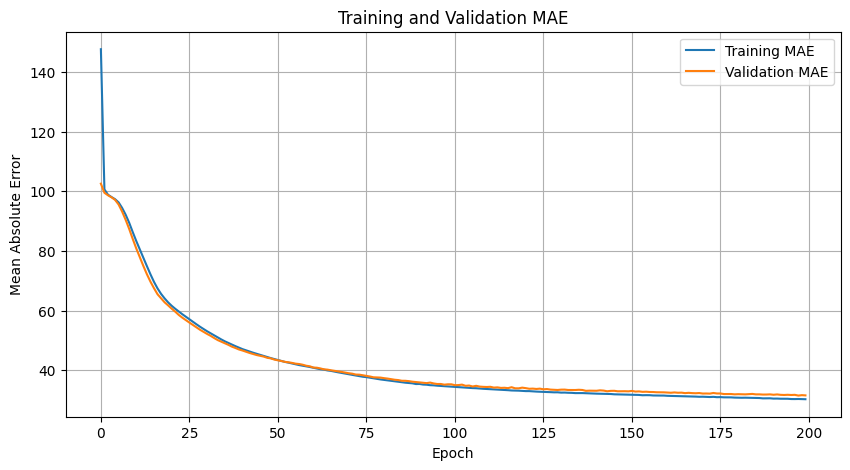

In [7]:
import matplotlib.pyplot as plt

training_mae = history.history["mae"]
validation_mae = history.history["val_mae"]

plt.figure(figsize=(10, 5))

plt.plot(training_mae, label="Training MAE")
plt.plot(validation_mae, label="Validation MAE")

plt.title("Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.grid(True)

plt.show()

### Baseline training

Training and validation MAE decreased together and remained close throughout training. This indicates stable learning without clear overfitting, although the improvement became smaller during the later epochs.


In [8]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Gör förutsägelser på valideringsdatan
y_val_pred = model.predict(X_val_scaled).flatten()

# Beräkna resultat
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

print("Validation MAE:", round(val_mae, 2))
print("Validation RMSE:", round(val_rmse, 2))
print("Validation R²:", round(val_r2, 3))

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Validation MAE: 31.46
Validation RMSE: 49.38
Validation R²: 0.925


### Baseline validation result

The baseline neural network achieved MAE = 31.46, RMSE = 49.38 and R² = 0.925 on the validation set. It therefore explained 92.5% of the variation, with an average absolute error of approximately 31 bikes.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

# Spara basmodellens resultat
results = [
    {
        "Model": "Baseline 32-64",
        "Dropout": 0.0,
        "Validation MAE": val_mae,
        "Validation RMSE": val_rmse,
        "Validation R²": val_r2
    }
]

# Bygg modell 2
model_2 = Sequential([
    Input(shape=(11,)),

    Dense(128, activation="relu"),
    Dropout(0.1),

    Dense(64, activation="relu"),
    Dropout(0.1),

    Dense(32, activation="relu"),

    Dense(1)
])

model_2.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae"]
)

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping_2 = EarlyStopping(
    monitor="val_mae",
    patience=15,
    restore_best_weights=True
)

checkpoint_2 = ModelCheckpoint(
    "model_2_best.keras",
    monitor="val_mae",
    save_best_only=True,
    mode="min",
    verbose=0
)

history_2 = model_2.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping_2, checkpoint_2],
    verbose=1
)

best_epoch_2 = np.argmin(history_2.history["val_mae"]) + 1

print("Antal genomförda epoker:", len(history_2.history["loss"]))
print("Bästa epoch:", best_epoch_2)
print("Bästa validation MAE:", min(history_2.history["val_mae"]))

Epoch 1/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 120.0600 - mae: 120.0600 - val_loss: 98.8910 - val_mae: 98.8910
Epoch 2/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 97.9907 - mae: 97.9907 - val_loss: 94.9297 - val_mae: 94.9297
Epoch 3/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 92.7443 - mae: 92.7443 - val_loss: 87.1253 - val_mae: 87.1253
Epoch 4/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 85.0277 - mae: 85.0277 - val_loss: 77.6990 - val_mae: 77.6990
Epoch 5/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 78.5179 - mae: 78.5179 - val_loss: 72.1434 - val_mae: 72.1434
Epoch 6/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 74.9856 - mae: 74.9856 - val_loss: 68.7125 - val_mae: 68.7125
Epoch 7/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 71.9211 - mae: 71.9211 - val_loss: 66.7713 - val_mae: 66.7713
Epoch 8/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 69.5245 - mae: 69.5245 - val_loss: 63.7743 - val_mae: 63.7743
Epoch 9/200
34

In [11]:
from tensorflow.keras.models import load_model

# Ladda modellen som ModelCheckpoint sparade
best_model_2 = load_model("model_2_best.keras")

# Förutsäg valideringsdatan
y_val_pred_2 = best_model_2.predict(X_val_scaled).flatten()

# Beräkna resultaten
val_mae_2 = mean_absolute_error(y_val, y_val_pred_2)
val_rmse_2 = np.sqrt(mean_squared_error(y_val, y_val_pred_2))
val_r2_2 = r2_score(y_val, y_val_pred_2)

# Lägg till resultatet i jämförelsetabellen
results.append(
    {
        "Model": "128-64-32 + Dropout 0.1",
        "Dropout": 0.1,
        "Validation MAE": val_mae_2,
        "Validation RMSE": val_rmse_2,
        "Validation R²": val_r2_2
    }
)

results_df = pd.DataFrame(results)

print(results_df.round(3))

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                     Model  Dropout  Validation MAE  Validation RMSE  \
0           Baseline 32-64      0.0          31.460           49.381   
1  128-64-32 + Dropout 0.1      0.1          27.576           44.063   

   Validation R²  
0          0.925  
1          0.940  


### Effect of a larger network and dropout

Increasing the network to 128–64–32 neurons and adding 0.1 dropout reduced validation MAE from 31.460 to 27.576 and increased R² from 0.925 to 0.940. The larger architecture clearly improved prediction performance.


In [12]:
model_3 = Sequential([
    Input(shape=(11,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])

model_3.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae"]
)

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stopping_3 = EarlyStopping(
    monitor="val_mae",
    patience=15,
    restore_best_weights=True
)

checkpoint_3 = ModelCheckpoint(
    "model_3_best.keras",
    monitor="val_mae",
    save_best_only=True,
    mode="min",
    verbose=0
)

history_3 = model_3.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping_3, checkpoint_3],
    verbose=1
)

best_epoch_3 = np.argmin(history_3.history["val_mae"]) + 1

print("Antal genomförda epoker:", len(history_3.history["loss"]))
print("Bästa epoch:", best_epoch_3)
print("Bästa validation MAE:", min(history_3.history["val_mae"]))

Epoch 1/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 120.6718 - mae: 120.6718 - val_loss: 98.9757 - val_mae: 98.9757
Epoch 2/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 97.5828 - mae: 97.5828 - val_loss: 95.1681 - val_mae: 95.1681
Epoch 3/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 92.0896 - mae: 92.0896 - val_loss: 86.2803 - val_mae: 86.2803
Epoch 4/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 82.4563 - mae: 82.4563 - val_loss: 77.2462 - val_mae: 77.2462
Epoch 5/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 75.4791 - mae: 75.4791 - val_loss: 71.6175 - val_mae: 71.6175
Epoch 6/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 70.8967 - mae: 70.8967 - val_loss: 68.2396 - val_mae: 68.2396
Epoch 7/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 67.6510 - mae: 67.6510 - val_loss: 65.3820 - val_mae: 65.3820
Epoch 8/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 65.2046 - mae: 65.2046 - val_loss: 63.4632 - val_mae: 63.4632
Epoch 9/200
34

In [14]:
# Ladda den bästa sparade versionen
best_model_3 = load_model("model_3_best.keras")

# Gör förutsägelser på valideringsdatan
y_val_pred_3 = best_model_3.predict(X_val_scaled).flatten()

# Beräkna resultat
val_mae_3 = mean_absolute_error(y_val, y_val_pred_3)
val_rmse_3 = np.sqrt(mean_squared_error(y_val, y_val_pred_3))
val_r2_3 = r2_score(y_val, y_val_pred_3)

# Lägg till modell 3 i tabellen
results.append(
    {
        "Model": "128-64-32 without Dropout",
        "Dropout": 0.0,
        "Validation MAE": val_mae_3,
        "Validation RMSE": val_rmse_3,
        "Validation R²": val_r2_3
    }
)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    "Validation MAE"
).reset_index(drop=True)

print(results_df.round(3))

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                       Model  Dropout  Validation MAE  Validation RMSE  \
0  128-64-32 without Dropout      0.0          27.236           44.197   
1    128-64-32 + Dropout 0.1      0.1          27.576           44.063   
2             Baseline 32-64      0.0          31.460           49.381   

   Validation R²  
0          0.940  
1          0.940  
2          0.925  


### Neural-network comparison

The 128–64–32 model without dropout achieved the lowest validation MAE (27.236). The dropout model had a marginally lower RMSE, but both models had R² = 0.940. Because MAE was the primary objective, the model without dropout was selected.


In [15]:
# Bästa modellen
best_model = best_model_3

# Förutsäg den orörda testdatan
y_test_pred = best_model.predict(X_test_scaled).flatten()

# Beräkna slutliga testresultat
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("FINAL TEST RESULTS")
print("Best model: 128-64-32 without Dropout")
print("Test MAE:", round(test_mae, 2))
print("Test RMSE:", round(test_rmse, 2))
print("Test R²:", round(test_r2, 3))

# Spara den slutliga modellen
best_model.save("best_bikesharing_nn.keras")

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
FINAL TEST RESULTS
Best model: 128-64-32 without Dropout
Test MAE: 26.76
Test RMSE: 44.29
Test R²: 0.938


### Final test performance

The selected model achieved MAE = 26.762, RMSE = 44.288 and R² = 0.938 on the untouched test set. These values are close to the validation results, indicating good generalization to unseen data.


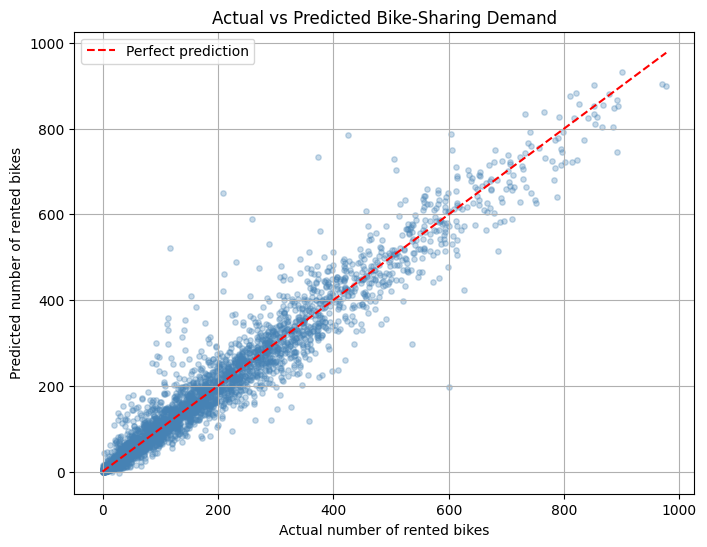

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.3,
    s=15,
    color="steelblue"
)

# Röd linje visar perfekta förutsägelser
maximum = max(y_test.max(), y_test_pred.max())

plt.plot(
    [0, maximum],
    [0, maximum],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.title("Actual vs Predicted Bike-Sharing Demand")
plt.xlabel("Actual number of rented bikes")
plt.ylabel("Predicted number of rented bikes")
plt.legend()
plt.grid(True)

plt.show()

### Actual versus predicted demand

Most observations lie close to the diagonal reference line, showing strong agreement between actual and predicted demand. The errors become wider at high demand levels, and some peak values are underestimated.


In [17]:
from sklearn.linear_model import LinearRegression

# Träna linjär regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Förutsäg testdatan
y_test_pred_linear = linear_model.predict(X_test_scaled)

# Beräkna resultat
linear_mae = mean_absolute_error(y_test, y_test_pred_linear)
linear_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_linear)
)
linear_r2 = r2_score(y_test, y_test_pred_linear)

comparison = pd.DataFrame([
    {
        "Model": "Neural Network 128-64-32",
        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Test R²": test_r2
    },
    {
        "Model": "Linear Regression",
        "Test MAE": linear_mae,
        "Test RMSE": linear_rmse,
        "Test R²": linear_r2
    }
])

print(comparison.round(3))

                      Model  Test MAE  Test RMSE  Test R²
0  Neural Network 128-64-32    26.762     44.288    0.938
1         Linear Regression   104.914    139.291    0.387


### Comparison with linear regression

The neural network substantially outperformed linear regression: test MAE decreased from 104.914 to 26.762 and R² increased from 0.387 to 0.938. This suggests that bike-sharing demand contains important nonlinear relationships.


In [18]:
import joblib

# Spara standardiseringen
joblib.dump(scaler, "bike_sharing_scaler.pkl")

# Spara resultattabeller
results_df.to_csv(
    "nn_validation_results.csv",
    index=False
)

comparison.to_csv(
    "test_model_comparison.csv",
    index=False
)

print("Saved files:")
print("- best_bikesharing_nn.keras")
print("- bike_sharing_scaler.pkl")
print("- nn_validation_results.csv")
print("- test_model_comparison.csv")

Saved files:
- best_bikesharing_nn.keras
- bike_sharing_scaler.pkl
- nn_validation_results.csv
- test_model_comparison.csv


## Final Results Summary

Three neural network configurations were evaluated for hourly bike-sharing demand prediction. The models used 11 weather, calendar and time-related input variables, while `cnt` was the output variable. The data were divided into 64% training, 16% validation and 20% testing. All input variables were standardized using statistics calculated only from the training data.

The baseline network with hidden layers of 32 and 64 neurons achieved a validation MAE of 31.460. Increasing the network size to 128–64–32 neurons improved the performance. The version with 0.1 dropout achieved a validation MAE of 27.576, while the same network without dropout achieved the lowest validation MAE of 27.236.

Therefore, the 128–64–32 network without dropout was selected as the best model. On the untouched test set, it achieved an MAE of 26.762, an RMSE of 44.288 and an R² of 0.938. In comparison, linear regression achieved an MAE of 104.914, an RMSE of 139.291 and an R² of 0.387. The neural network therefore captured the nonlinear relationships in bike-sharing demand substantially better.

